# Pertemuan 9 - Data Science

**Nama:** Krisno Hasmilu Hutabarat  
**NIM:** 240401010102  
**Kelas:** IF401  
**Mata Kuliah:** Data Science

---
## Langkah 0: Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (confusion_matrix, accuracy_score,
                              precision_score, recall_score, f1_score)

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


---
## Langkah 1: Load & Eksplorasi Dataset (EDA)

In [2]:
# Load dataset Breast Cancer Wisconsin
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = malignant, 1 = benign

print('Shape:', X.shape)
print()
print(X.describe().round(2).iloc[:, :5])  # tampilkan 5 fitur pertama saja

Shape: (569, 30)

       mean radius  mean texture  mean perimeter  mean area  mean smoothness
count       569.00        569.00          569.00     569.00           569.00
mean         14.13         19.29           91.97     654.89             0.10
std           3.52          4.30           24.30     351.91             0.01
min           6.98          9.71           43.79     143.50             0.05
25%          11.70         16.17           75.17     420.30             0.09
50%          13.37         18.84           86.24     551.10             0.10
75%          15.78         21.80          104.10     782.70             0.11
max          28.11         39.28          188.50    2501.00             0.16


In [3]:
# Distribusi target
dist = pd.Series(y).value_counts(normalize=True).round(3)
dist.index = ['Malignant (0)', 'Benign (1)']
print('Distribusi target:')
print(dist)

Distribusi target:
Malignant (0)    0.627
Benign (1)       0.373
Name: proportion, dtype: float64


/tmp/ipykernel_1421/4012598944.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='Set2')


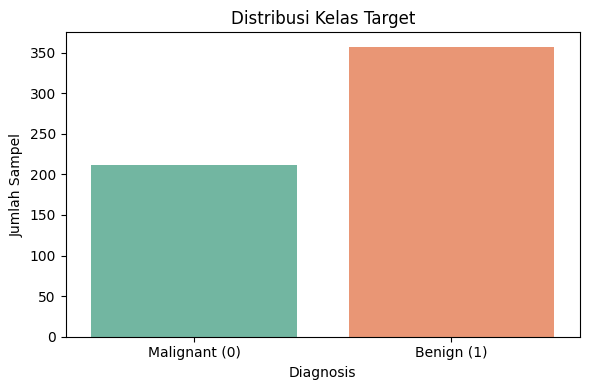

In [4]:
# EDA: Distribusi target secara visual
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='Set2')
plt.xticks([0, 1], ['Malignant (0)', 'Benign (1)'])
plt.title('Distribusi Kelas Target')
plt.xlabel('Diagnosis')
plt.ylabel('Jumlah Sampel')
plt.tight_layout()
plt.show()

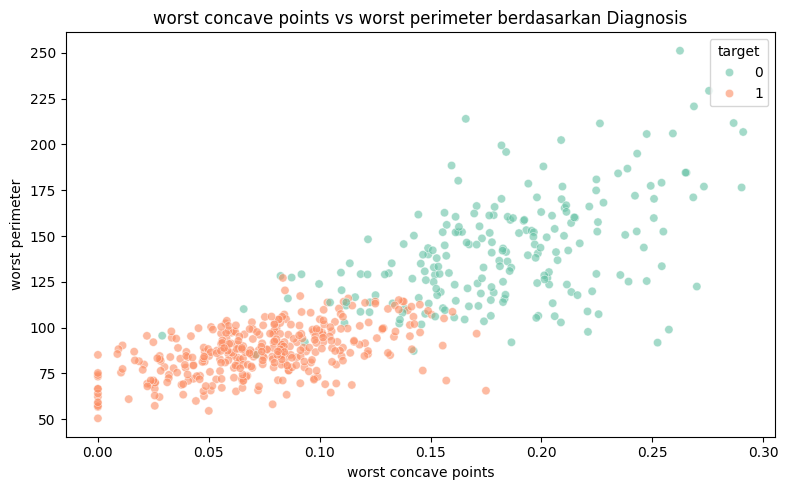

In [5]:
# EDA: Scatter plot dua fitur dengan korelasi tertinggi terhadap target
df_corr = X.copy()
df_corr['target'] = y
top2 = df_corr.corr()['target'].abs().sort_values(ascending=False).index[1:3]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_corr, x=top2[0], y=top2[1],
                hue='target', palette='Set2', alpha=0.6)
plt.title(f'{top2[0]} vs {top2[1]} berdasarkan Diagnosis')
plt.tight_layout()
plt.show()

### Interpretasi EDA
- Kelas target sedikit **tidak seimbang** — proporsi Benign (1) lebih besar dibanding Malignant (0).
- Dua fitur dengan korelasi tertinggi terhadap target menunjukkan **pemisahan yang cukup jelas** antar kelas pada scatter plot.
- Karena kelas tidak seimbang, **Accuracy saja tidak cukup** untuk mengukur performa model — Precision, Recall, dan F1-Score perlu diperhatikan (dibahas pada Langkah 5).

---
## Langkah 2: Preprocessing

In [6]:
# Train-Test Split (80:20) dengan stratify=y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Jumlah data training : {X_train.shape[0]} baris')
print(f'Jumlah data test      : {X_test.shape[0]} baris')

Jumlah data training : 455 baris
Jumlah data test      : 114 baris


In [7]:
# StandardScaler — fit HANYA pada training set (untuk Logistic Regression)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)  # hanya transform, bukan fit_transform!

print('Scaling selesai.')
print('Mean scaler (5 fitur pertama):', scaler.mean_[:5].round(3))
print('Std  scaler (5 fitur pertama):', scaler.scale_[:5].round(3))

Scaling selesai.
Mean scaler (5 fitur pertama): [1.40670e+01 1.92470e+01 9.15570e+01 6.48541e+02 9.60000e-02]
Std  scaler (5 fitur pertama): [3.49600e+00 4.40000e+00 2.41230e+01 3.44565e+02 1.30000e-02]


**Catatan:** Decision Tree pada Langkah 4 akan dilatih menggunakan `X_train`/`X_test` **tanpa scaling**, karena Decision Tree tidak sensitif terhadap skala fitur.

---
## Langkah 3: Latih Logistic Regression

In [8]:
# Buat dan latih model Logistic Regression
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)

y_pred_log  = log_model.predict(X_test_s)
y_proba_log = log_model.predict_proba(X_test_s)[:, 1]

print(f'β0 (intercept): {log_model.intercept_[0]:.4f}')

β0 (intercept): 0.3022


In [9]:
# Tampilkan koefisien dalam tabel (diurutkan berdasar besar pengaruh)
coef_df = pd.DataFrame({
    'Fitur'     : X.columns,
    'Koefisien' : log_model.coef_[0].round(4)
}).sort_values('Koefisien', key=abs, ascending=False)

print(coef_df.head(10).to_string(index=False))

               Fitur  Koefisien
       worst texture    -1.2551
        radius error    -1.0830
worst concave points    -0.9537
          worst area    -0.9478
        worst radius    -0.9476
      worst symmetry    -0.9392
          area error    -0.9291
     worst concavity    -0.8232
     worst perimeter    -0.7632
    worst smoothness    -0.7466


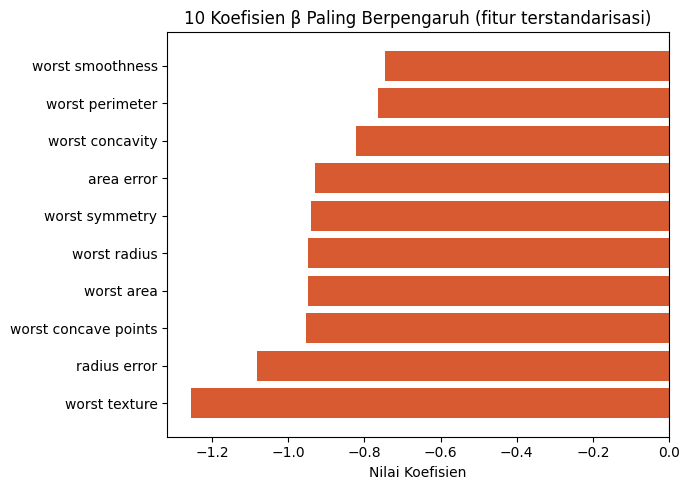

In [10]:
# Visualisasi 10 koefisien paling berpengaruh
top10 = coef_df.head(10).sort_values('Koefisien')
colors = ['#1D9E75' if v >= 0 else '#D85A30' for v in top10['Koefisien']]

plt.figure(figsize=(7, 5))
plt.barh(top10['Fitur'], top10['Koefisien'], color=colors)
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title('10 Koefisien β Paling Berpengaruh (fitur terstandarisasi)')
plt.xlabel('Nilai Koefisien')
plt.tight_layout()
plt.show()

### Interpretasi Koefisien
- Koefisien dengan nilai **absolut terbesar** adalah fitur yang paling kuat mempengaruhi keputusan model.
- Koefisien **positif** mendorong prediksi ke arah kelas 1 (Benign), sedangkan koefisien **negatif** mendorong ke arah kelas 0 (Malignant).
- Fitur-fitur terkait ukuran sel (radius, perimeter, area) umumnya memiliki bobot besar — semakin besar ukurannya, semakin condong ke arah Malignant.

---
## Langkah 4: Latih Decision Tree

In [11]:
# Decision Tree dilatih pada data ASLI (tanpa scaling)
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree  = tree_model.predict(X_test)
y_proba_tree = tree_model.predict_proba(X_test)[:, 1]

print('Decision Tree berhasil dilatih.')
print(f'Kedalaman pohon (max_depth) : {tree_model.get_depth()}')
print(f'Jumlah leaf node            : {tree_model.get_n_leaves()}')

Decision Tree berhasil dilatih.
Kedalaman pohon (max_depth) : 4
Jumlah leaf node            : 11


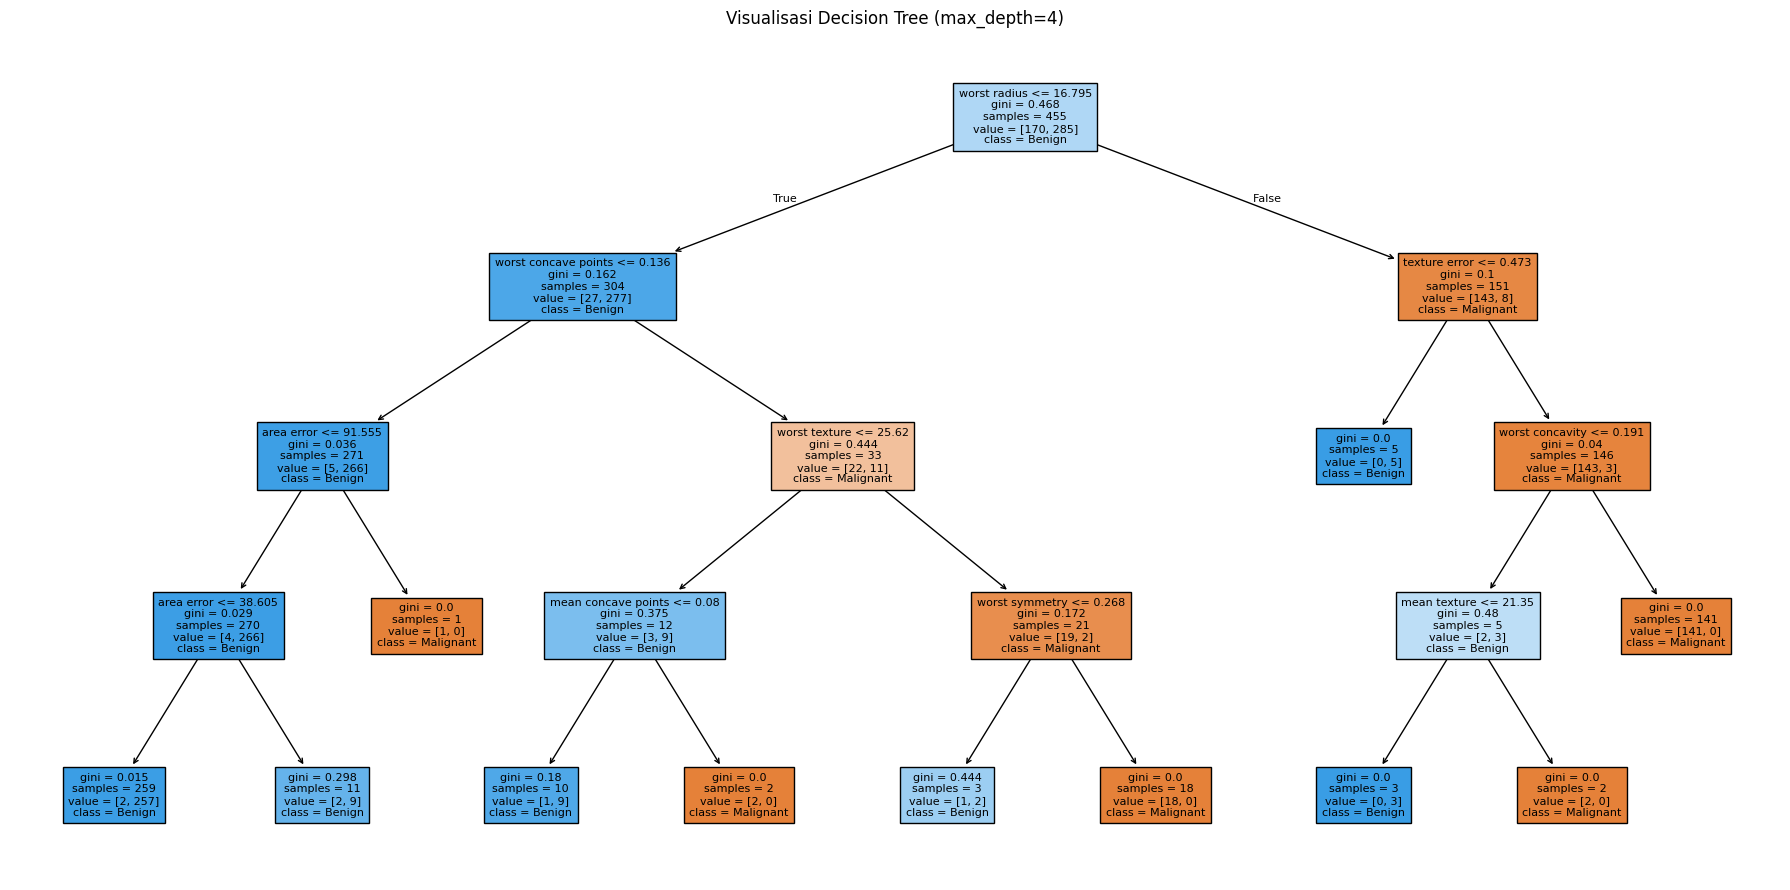

In [12]:
# Visualisasi pohon keputusan
plt.figure(figsize=(18, 9))
plot_tree(tree_model, feature_names=X.columns,
          class_names=['Malignant', 'Benign'], filled=True, fontsize=8)
plt.title('Visualisasi Decision Tree (max_depth=4)')
plt.tight_layout()
plt.show()

In [13]:
# Feature importance
importance_df = pd.DataFrame({
    'Fitur'      : X.columns,
    'Importance' : tree_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df.head(10).to_string(index=False))

               Fitur  Importance
        worst radius    0.733548
worst concave points    0.122028
       texture error    0.045785
       worst texture    0.032319
     worst concavity    0.017161
 mean concave points    0.013327
          area error    0.012704
        mean texture    0.011846
      worst symmetry    0.011282
           mean area    0.000000


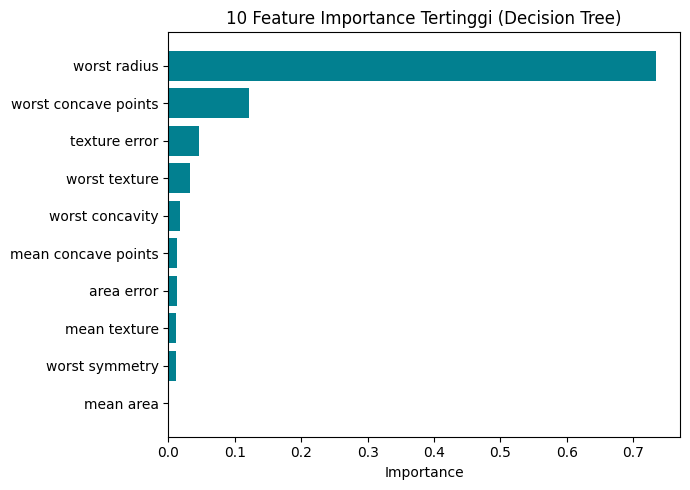

In [14]:
# Visualisasi feature importance
top10_imp = importance_df.head(10).sort_values('Importance')

plt.figure(figsize=(7, 5))
plt.barh(top10_imp['Fitur'], top10_imp['Importance'], color='#028090')
plt.title('10 Feature Importance Tertinggi (Decision Tree)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### Interpretasi Decision Tree
- **Root node** menggunakan fitur dengan kemampuan pemisahan kelas paling kuat, sesuai nilai Gini Impurity terendah.
- `feature_importances_` menunjukkan kontribusi setiap fitur terhadap pengurangan impurity di seluruh pohon — fitur dengan nilai tertinggi adalah yang paling sering dan paling efektif digunakan untuk split.
- Pohon dibatasi dengan `max_depth=4` untuk menjaga keseimbangan antara kemampuan menangkap pola dan risiko overfitting.

---
## Langkah 5: Evaluasi Model

In [15]:
results = {}

for name, y_pred in [('Logistic Regression', y_pred_log),
                      ('Decision Tree', y_pred_tree)]:
    cm   = confusion_matrix(y_test, y_pred)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    print('=' * 40)
    print(f'  {name}')
    print('=' * 40)
    print('Confusion Matrix:')
    print(cm)
    print(f'Accuracy  = {acc:.4f}')
    print(f'Precision = {prec:.4f}')
    print(f'Recall    = {rec:.4f}')
    print(f'F1-Score  = {f1:.4f}')
    print()

    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

  Logistic Regression
Confusion Matrix:
[[41  1]
 [ 1 71]]
Accuracy  = 0.9825
Precision = 0.9861
Recall    = 0.9861
F1-Score  = 0.9861

  Decision Tree
Confusion Matrix:
[[39  3]
 [ 4 68]]
Accuracy  = 0.9386
Precision = 0.9577
Recall    = 0.9444
F1-Score  = 0.9510



In [16]:
# Tabel ringkasan perbandingan kedua model
summary_df = pd.DataFrame(results).T.round(4)
summary_df

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.9825,0.9861,0.9861,0.9861
Decision Tree,0.9386,0.9577,0.9444,0.9510


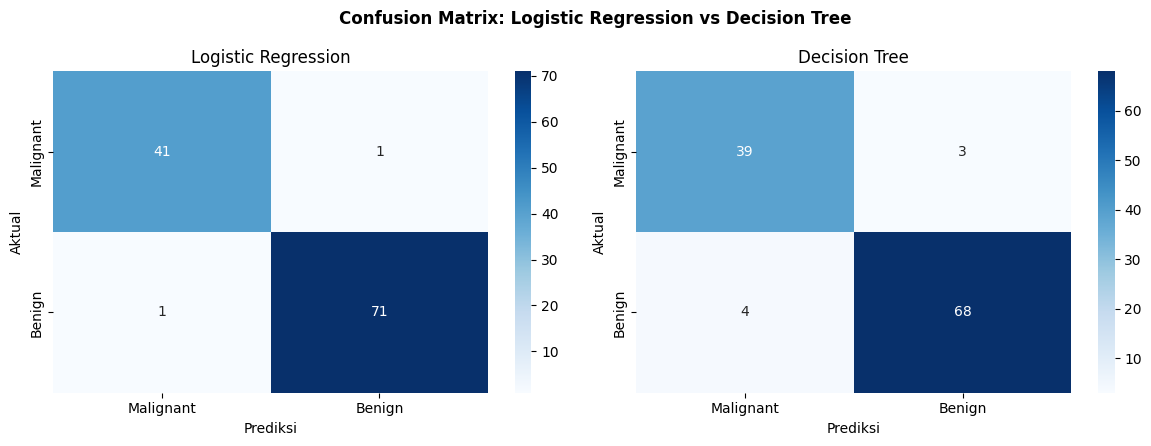

In [17]:
# Visualisasi confusion matrix kedua model berdampingan
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (name, y_pred) in zip(axes, [('Logistic Regression', y_pred_log),
                                       ('Decision Tree', y_pred_tree)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'])
    ax.set_title(name)
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.suptitle('Confusion Matrix: Logistic Regression vs Decision Tree', fontweight='bold')
plt.tight_layout()
plt.show()

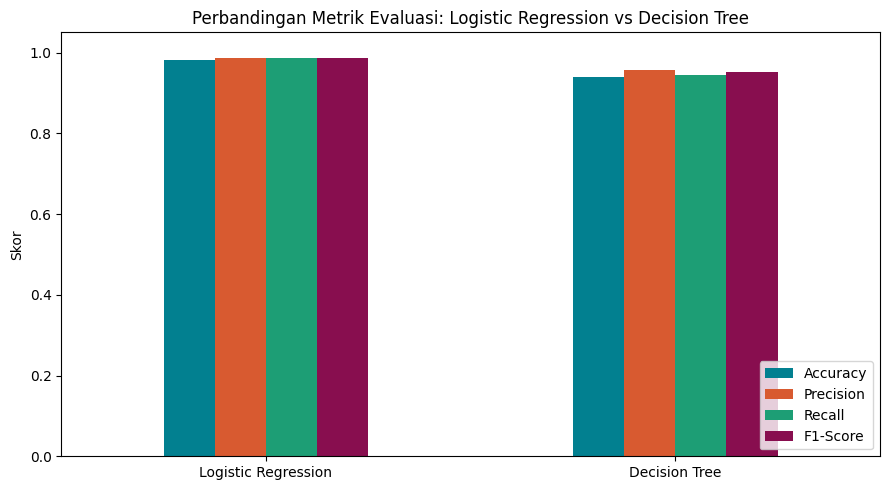

In [18]:
# Visualisasi perbandingan metrik antar model
summary_df.plot(kind='bar', figsize=(9, 5), color=['#028090', '#D85A30', '#1D9E75', '#880E4F'])
plt.title('Perbandingan Metrik Evaluasi: Logistic Regression vs Decision Tree')
plt.ylabel('Skor')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Interpretasi Metrik Evaluasi

| Metrik | Fokus | Mengapa penting di kasus ini |
|--------|-------|-------------------------------|
| Accuracy | Ketepatan umum | Bisa menyesatkan karena kelas tidak seimbang |
| Precision | Minimalkan False Positive | Penting bila pemeriksaan lanjutan yang tidak perlu ingin diminimalkan |
| **Recall** | **Minimalkan False Negative** | **Paling kritis** — False Negative berarti kasus Malignant yang terlewat |
| F1-Score | Keseimbangan Precision & Recall | Berguna untuk menilai performa keseluruhan secara ringkas |

**Perbandingan kedua model (lihat `summary_df` di atas):**
- Bandingkan nilai **Recall** dari Logistic Regression vs Decision Tree — model dengan Recall lebih tinggi lebih jarang melewatkan kasus positif yang sebenarnya.
- Pada konteks diagnosis kanker, **Recall lebih penting daripada Accuracy**, karena False Negative (pasien sakit yang dikira sehat) jauh lebih berbahaya dibanding False Positive (pasien sehat yang direkomendasikan periksa ulang).
- Jika selisih metrik antar kedua model relatif kecil, performa keduanya dapat dikatakan **tidak berbeda signifikan** pada dataset ini — Logistic Regression cenderung sedikit lebih stabil karena hubungan fitur-target yang cukup linear, sedangkan Decision Tree menawarkan keunggulan interpretasi visual melalui struktur pohonnya.

## Kesimpulan

Pada pertemuan ini, saya mempelajari Algoritma Klasifikasi menggunakan Logistic Regression dan Decision Tree pada dataset Breast Cancer Wisconsin. Tahapan yang dilakukan meliputi eksplorasi data, train-test split dengan stratifikasi, scaling fitur (khusus Logistic Regression), pelatihan kedua model, interpretasi koefisien dan feature importance, hingga evaluasi menggunakan Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score.

Temuan utama dari praktikum ini adalah pentingnya memilih metrik evaluasi yang sesuai dengan konteks permasalahan — pada kasus diagnosis medis, Recall menjadi metrik paling kritis dibandingkan Accuracy karena False Negative (kasus Malignant yang terlewat) memiliki konsekuensi yang jauh lebih berbahaya daripada False Positive. Keterbatasannya adalah dataset ini relatif bersih dan terstruktur, sehingga performa model belum tentu sama baiknya jika diterapkan pada data klinis nyata yang lebih kompleks dan tidak seimbang.